# Visualize the Five-Condition A–E Analysis

This notebook uses the CSV files produced by the matched-image repeated-measures analysis and creates three publication-style visualizations:

1. **Omnibus effect-size matrix**  
   Shows where condition A/B/C/D/E has an overall effect.

2. **Post-hoc pairwise matrices**  
   Shows which specific condition pairs differ, including B–C, C–D, and C–E.

3. **Connected repeated-measures plot for CTA VAI**  
   Shows how the same 20 ad images change across A → B → C → D → E.

### Expected files

Put these files in the same folder as this notebook:

```text
A_to_E_long_image_level_data.csv
A_to_E_repeated_measures_omnibus.csv
A_to_E_repeated_measures_posthoc.csv
```

If your files are in a `data` folder, keep the paths below as written.


In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


## 1. File paths and configuration

In [2]:
# If the CSVs are in the same folder as the notebook, remove 'data/'.
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
OMNIBUS_CSV = "data/A_to_E_repeated_measures_omnibus.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

ALPHA = 0.05

AOI_ORDER = ["CTA", "Headline", "Product"]

METRIC_ORDER = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

PAIR_ORDER = [
    "A-B", "A-C", "A-D", "A-E",
    "B-C", "B-D", "B-E",
    "C-D", "C-E",
    "D-E",
]

CONDITION_ORDER = ["A", "B", "C", "D", "E"]

OUT_OMNIBUS_PNG = "figure_omnibus_effect_matrix.png"
OUT_OMNIBUS_PDF = "figure_omnibus_effect_matrix.pdf"

OUT_POSTHOC_PREFIX = "figure_posthoc_matrix"

OUT_CTA_VAI_PNG = "figure_CTA_VAI_connected.png"
OUT_CTA_VAI_PDF = "figure_CTA_VAI_connected.pdf"


## 2. Load the three analysis files

In [3]:
for f in [LONG_CSV, OMNIBUS_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(
            f"Could not find: {f}\n"
            "Check the filename or edit the path in the configuration cell."
        )

long_df = pd.read_csv(LONG_CSV)
omnibus = pd.read_csv(OMNIBUS_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, omnibus, posthoc]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

print("Long data rows:", len(long_df))
print("Omnibus rows:", len(omnibus))
print("Post-hoc rows:", len(posthoc))


Long data rows: 2400
Omnibus rows: 24
Post-hoc rows: 140


# Figure 1 — Omnibus effect-size matrix

### Encoding

- **Rows** = metrics, grouped by CTA / Headline / Product
- **Cell intensity** = omnibus effect size, \(\eta^2\)
- **Black border** = omnibus result survives BH-FDR
- **Text inside significant cells** = FDR-adjusted \(q\)-value

This answers:

> For which AOI × metric does the five-condition manipulation have an overall effect?


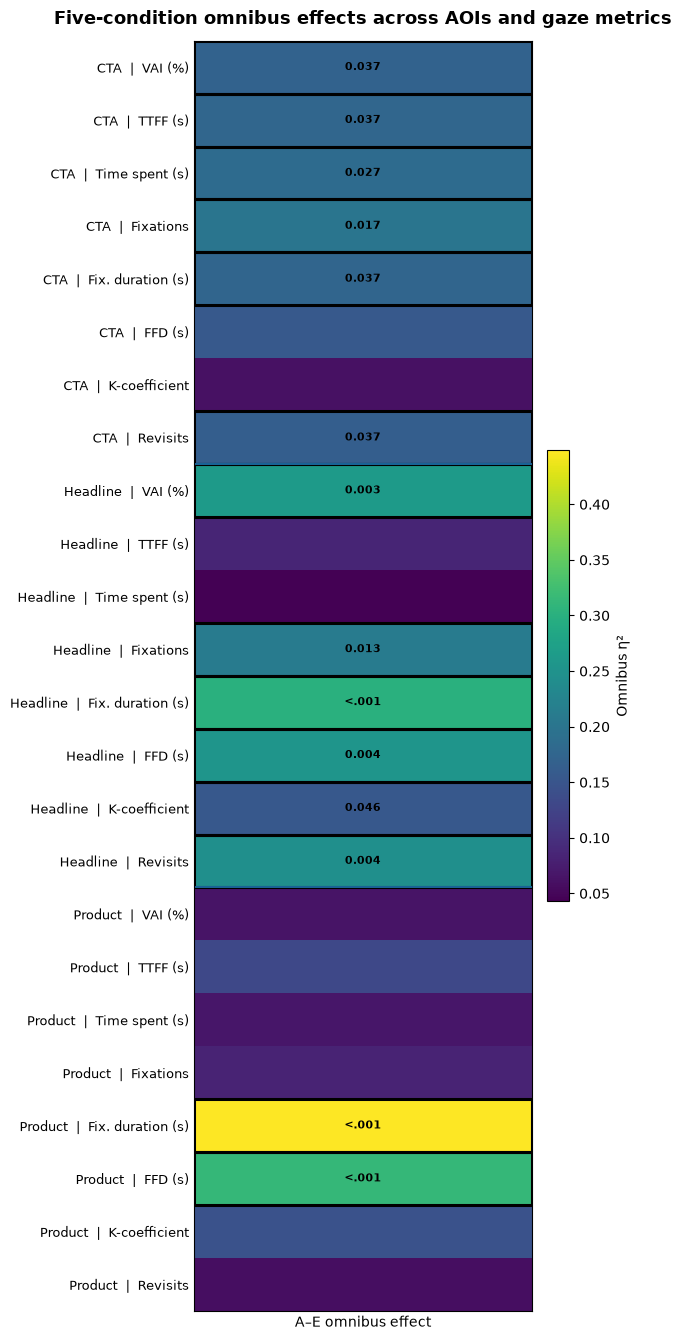

Saved: figure_omnibus_effect_matrix.png
Saved: figure_omnibus_effect_matrix.pdf


In [4]:
# Build one combined matrix: 24 rows × 1 quantitative column.
# Keeping everything in one axes makes the AOI blocks easy to compare.

plot_rows = []

for aoi in AOI_ORDER:
    for metric in METRIC_ORDER:
        sub = omnibus[
            (omnibus["AOI"] == aoi)
            & (omnibus["metric"] == metric)
        ]

        if len(sub) == 0:
            plot_rows.append({
                "AOI": aoi,
                "metric": metric,
                "eta_sq": np.nan,
                "q": np.nan,
                "sig": False,
            })
        else:
            r = sub.iloc[0]
            plot_rows.append({
                "AOI": aoi,
                "metric": metric,
                "eta_sq": float(r["eta_sq"]),
                "q": float(r["q_omnibus_FDR"]),
                "sig": bool(r["significant_omnibus_FDR"]),
            })

omni_plot = pd.DataFrame(plot_rows)

vals = omni_plot["eta_sq"].to_numpy().reshape(-1, 1)

fig, ax = plt.subplots(figsize=(6.5, 13.5))

im = ax.imshow(
    vals,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks([0])
ax.set_xticklabels(["A–E omnibus effect"])

y_labels = [f"{r.AOI}  |  {r.metric}" for _, r in omni_plot.iterrows()]
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=9)

# Add significance borders and q-values
for i, r in omni_plot.iterrows():
    if bool(r["sig"]):
        ax.add_patch(
            Rectangle(
                (-0.5, i - 0.5),
                1,
                1,
                fill=False,
                edgecolor="black",
                linewidth=2.2
            )
        )

        q = float(r["q"])
        qtxt = "<.001" if q < 0.001 else f"{q:.3f}"

        ax.text(
            0,
            i,
            qtxt,
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

# AOI separators
for sep in [7.5, 15.5]:
    ax.axhline(sep, linewidth=1.2)

cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
cbar.set_label("Omnibus η²")

ax.set_title(
    "Five-condition omnibus effects across AOIs and gaze metrics",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

fig.tight_layout()

fig.savefig(OUT_OMNIBUS_PNG, dpi=400, bbox_inches="tight")
fig.savefig(OUT_OMNIBUS_PDF, bbox_inches="tight")

plt.show()

print("Saved:", OUT_OMNIBUS_PNG)
print("Saved:", OUT_OMNIBUS_PDF)


# Figure 2 — Post-hoc pairwise matrices

For each AOI, this creates an **8 metrics × 10 pairwise comparisons** matrix.

### Encoding

- **Columns** = A–B, A–C, ..., C–E, D–E
- **Rows** = gaze metrics
- **Cell value** = standardized paired effect size \(d_z\)
- **Positive** = second condition is higher than the first
- **Negative** = second condition is lower than the first
- **Black border** = post-hoc comparison survives global post-hoc BH-FDR
- **Text** = FDR-adjusted \(q\)-value for significant comparisons

Using \(d_z\) instead of raw mean difference allows VAI, TTFF, Fixations, etc. to be shown on a more comparable standardized scale.


In [5]:
def paired_dz(x, y):
    """
    Standardized paired effect:
    dz = mean(y - x) / SD(y - x)
    """
    d = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    d = d[np.isfinite(d)]

    if len(d) < 2:
        return np.nan

    sd = np.std(d, ddof=1)

    if sd == 0:
        return 0.0

    return np.mean(d) / sd


effect_rows = []

for aoi in AOI_ORDER:
    for metric in METRIC_ORDER:

        sub_long = long_df[
            (long_df["AOI"] == aoi)
            & (long_df["metric"] == metric)
        ].copy()

        pivot = sub_long.pivot(
            index="Img",
            columns="condition",
            values="value"
        )

        for p in PAIR_ORDER:
            g1, g2 = p.split("-")

            if g1 not in pivot.columns or g2 not in pivot.columns:
                continue

            pair = pivot[[g1, g2]].dropna()

            dz = paired_dz(
                pair[g1].values,
                pair[g2].values
            )

            ph = posthoc[
                (posthoc["AOI"] == aoi)
                & (posthoc["metric"] == metric)
                & (
                    (
                        (posthoc["group1"] == g1)
                        & (posthoc["group2"] == g2)
                    )
                    |
                    (
                        (posthoc["group1"] == g2)
                        & (posthoc["group2"] == g1)
                    )
                )
            ]

            if len(ph) > 0:
                ph_r = ph.iloc[0]
                q = float(ph_r["q_posthoc_global_FDR"])
                sig = bool(ph_r["significant_posthoc_global_FDR"])
            else:
                q = np.nan
                sig = False

            effect_rows.append({
                "AOI": aoi,
                "metric": metric,
                "pair": p,
                "dz": dz,
                "q": q,
                "sig": sig,
            })

effect_df = pd.DataFrame(effect_rows)

effect_df.head()


,AOI,metric,pair,dz,q,sig
0,CTA,VAI (%),A-B,0.554590,0.221644,False
1,CTA,VAI (%),A-C,0.878400,0.034510,True
2,CTA,VAI (%),A-D,0.436254,0.221644,False
3,CTA,VAI (%),A-E,0.436764,0.262006,False
4,CTA,VAI (%),B-C,0.533477,0.134071,False


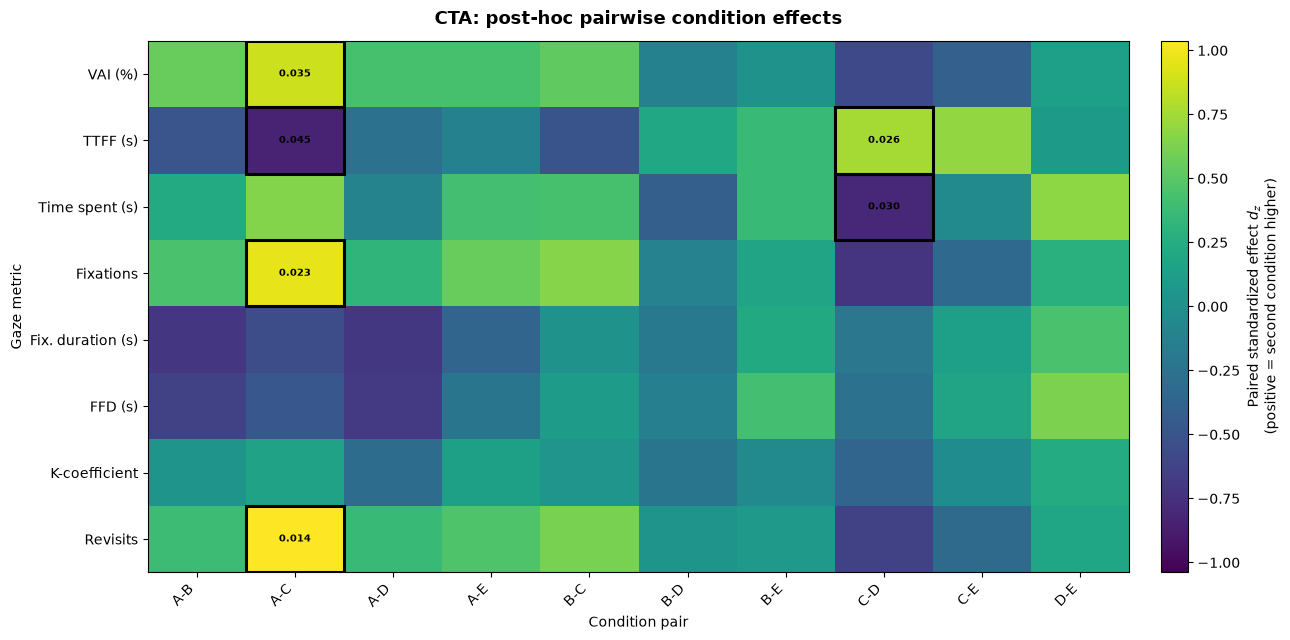

Saved: figure_posthoc_matrix_CTA.png
Saved: figure_posthoc_matrix_CTA.pdf


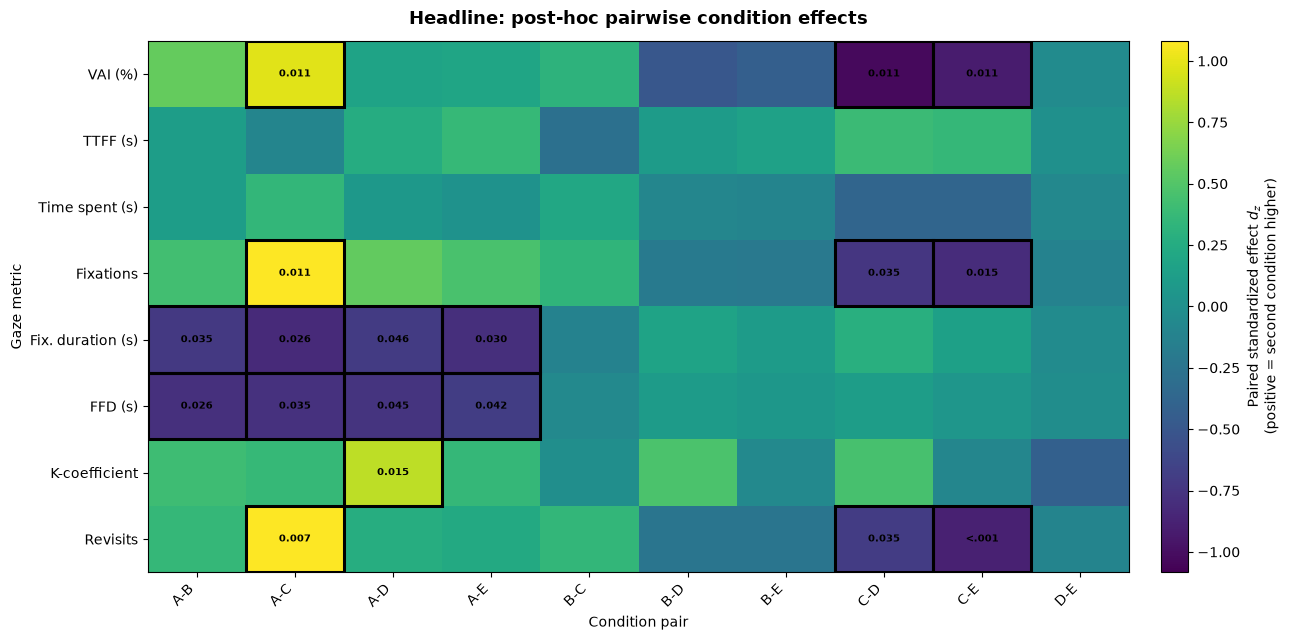

Saved: figure_posthoc_matrix_Headline.png
Saved: figure_posthoc_matrix_Headline.pdf


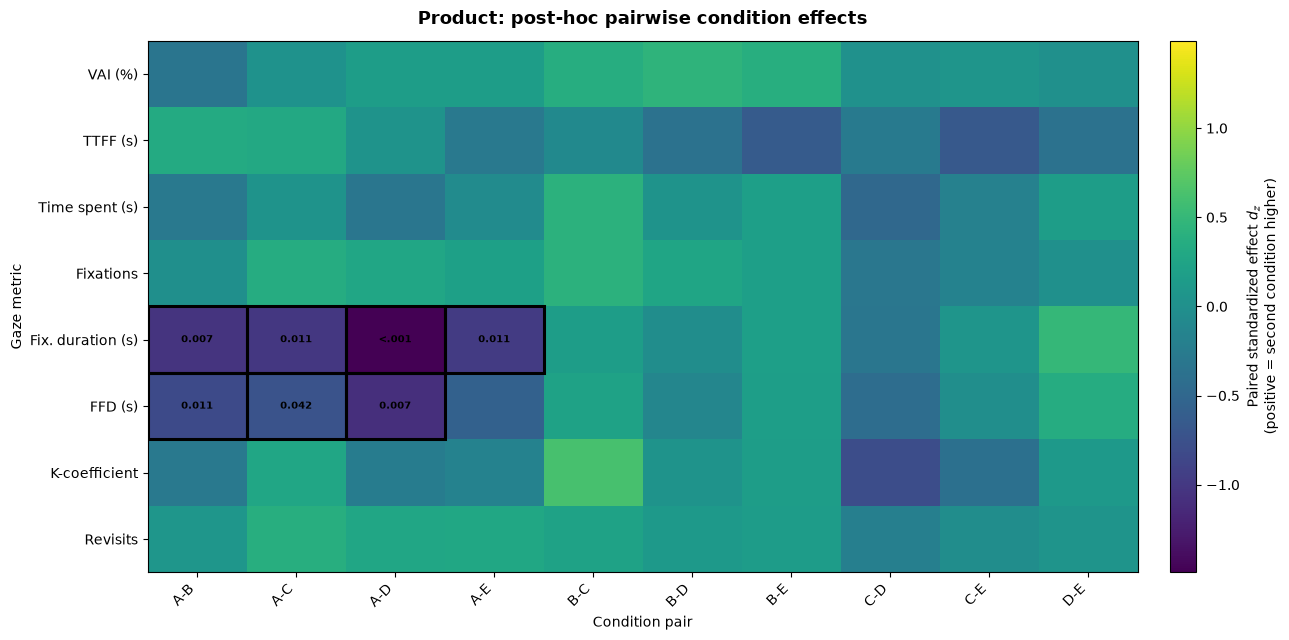

Saved: figure_posthoc_matrix_Product.png
Saved: figure_posthoc_matrix_Product.pdf


In [6]:
# Produce one matrix per AOI.
# This is clearer than forcing all 3 AOIs into one huge figure.

for aoi in AOI_ORDER:
    mat = np.full(
        (len(METRIC_ORDER), len(PAIR_ORDER)),
        np.nan
    )

    sig_map = {}
    q_map = {}

    for i, metric in enumerate(METRIC_ORDER):
        for j, pair in enumerate(PAIR_ORDER):
            sub = effect_df[
                (effect_df["AOI"] == aoi)
                & (effect_df["metric"] == metric)
                & (effect_df["pair"] == pair)
            ]

            if len(sub) == 0:
                continue

            r = sub.iloc[0]
            mat[i, j] = r["dz"]
            sig_map[(i, j)] = bool(r["sig"])
            q_map[(i, j)] = r["q"]

    vmax = np.nanmax(np.abs(mat))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(13, 6.5))

    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(PAIR_ORDER)))
    ax.set_xticklabels(PAIR_ORDER, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(METRIC_ORDER)))
    ax.set_yticklabels(METRIC_ORDER)

    # Borders and q-values only for globally significant post-hoc results
    for i in range(len(METRIC_ORDER)):
        for j in range(len(PAIR_ORDER)):
            if sig_map.get((i, j), False):
                ax.add_patch(
                    Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=2.2
                    )
                )

                q = q_map[(i, j)]
                qtxt = "<.001" if q < 0.001 else f"{q:.3f}"

                ax.text(
                    j,
                    i,
                    qtxt,
                    ha="center",
                    va="center",
                    fontsize=7,
                    fontweight="bold"
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label(
        "Paired standardized effect $d_z$\n"
        "(positive = second condition higher)"
    )

    ax.set_title(
        f"{aoi}: post-hoc pairwise condition effects",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Condition pair")
    ax.set_ylabel("Gaze metric")

    fig.tight_layout()

    png = f"{OUT_POSTHOC_PREFIX}_{aoi}.png"
    pdf = f"{OUT_POSTHOC_PREFIX}_{aoi}.pdf"

    fig.savefig(png, dpi=400, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    plt.show()

    print("Saved:", png)
    print("Saved:", pdf)


# Figure 3 — CTA VAI connected repeated-measures plot

This figure is intentionally simple.

Each thin line represents **one advertisement image** across conditions A–E.

This lets you see whether Condition C's CTA VAI effect is:

- consistent across many ads, or
- driven by only a few images.

A thicker mean line is added on top.


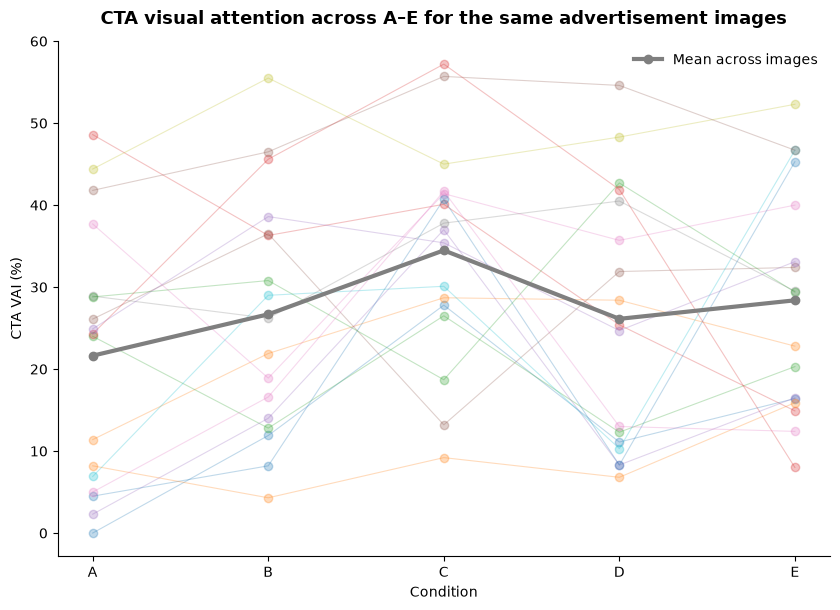

Matched images used: 17
Saved: figure_CTA_VAI_connected.png
Saved: figure_CTA_VAI_connected.pdf


In [7]:
focus = long_df[
    (long_df["AOI"] == "CTA")
    & (long_df["metric"] == "VAI (%)")
].copy()

pivot = focus.pivot(
    index="Img",
    columns="condition",
    values="value"
)

# Keep matched images only
pivot = pivot[
    [c for c in CONDITION_ORDER if c in pivot.columns]
].dropna()

x = np.arange(len(CONDITION_ORDER))

fig, ax = plt.subplots(figsize=(8.5, 6.2))

# One line per image
for img_id, row in pivot.iterrows():
    y = row[CONDITION_ORDER].astype(float).values

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=0.8,
        alpha=0.28
    )

# Overall mean across images
mean_values = pivot[CONDITION_ORDER].mean(axis=0).values

ax.plot(
    x,
    mean_values,
    marker="o",
    linewidth=3.0,
    label="Mean across images"
)

ax.set_xticks(x)
ax.set_xticklabels(CONDITION_ORDER)

ax.set_xlabel("Condition")
ax.set_ylabel("CTA VAI (%)")

ax.set_title(
    "CTA visual attention across A–E for the same advertisement images",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    OUT_CTA_VAI_PNG,
    dpi=400,
    bbox_inches="tight"
)

fig.savefig(
    OUT_CTA_VAI_PDF,
    bbox_inches="tight"
)

plt.show()

print("Matched images used:", len(pivot))
print("Saved:", OUT_CTA_VAI_PNG)
print("Saved:", OUT_CTA_VAI_PDF)


## How to read the three figures

### Figure 1 — Omnibus matrix
A black-bordered cell means:

\[
q_{\mathrm{omnibus}} < .05
\]

so the A–E condition factor significantly affects that AOI × metric.

### Figure 2 — Post-hoc matrices
For a pair such as `C-D`:

- positive \(d_z\) → D is higher than C
- negative \(d_z\) → D is lower than C
- black border → that specific pair survives global post-hoc FDR

Pay particular attention to:

```text
A-C
B-C
C-D
C-E
```

### Figure 3 — CTA VAI
Each line is the same ad viewed under A/B/C/D/E.

If many image trajectories rise toward C, that supports a broad C-related CTA effect rather than an effect driven by only a few advertisements.
